Loading data...

--- DATA CLEANING REPORT ---
Total laps initially: 424
Total laps removed (Pit, Out-laps, >1.5x median): 45
Laps remaining for modeling: 379

--- MODEL COMPARISON ---
Baseline Model (Grid & Lap only):
RMSE: 11.447s
MAE:  8.312s

Tire-Age Enhanced Model (+ Tire Age):
RMSE: 20.936s
MAE:  20.133s


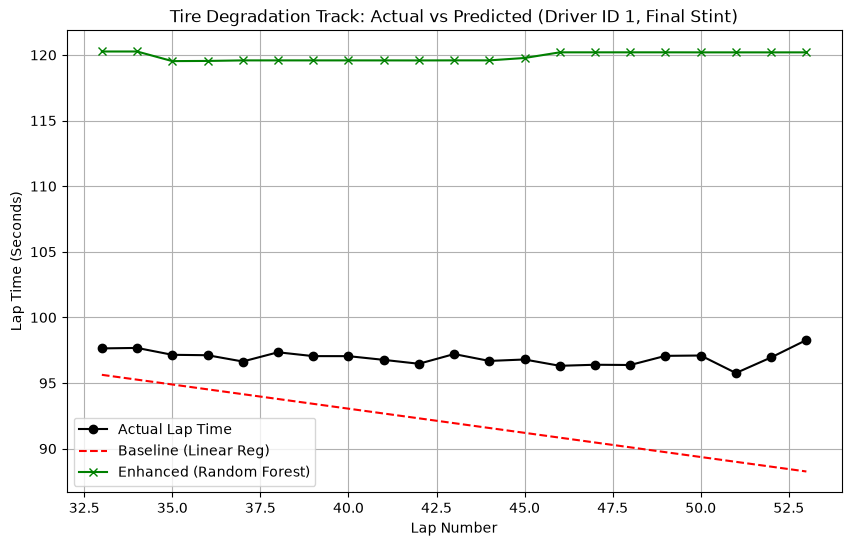

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

# ==========================================
# STEP 1: LOAD DATA & MERGE (Required Files)
# ==========================================
print("Loading data...")

# Note: os.getcwd() works perfectly in Jupyter Notebooks to find your current folder
current_folder = os.getcwd()

# Load all 4 required dataset files
laps = pd.read_csv(os.path.join(current_folder, 'lap_times.csv'))
pit_stops = pd.read_csv(os.path.join(current_folder, 'pit_stops.csv'))
results = pd.read_csv(os.path.join(current_folder, 'results.csv'))
races = pd.read_csv(os.path.join(current_folder, 'races.csv'))

# Select 2019 Italian GP (raceId = 1025) - Dry race, no red flags
TARGET_RACE_ID = 1025

# Get top 8 drivers who completed the race (Satisfies the 5 to 10 driver rubric rule)
race_results = results[(results['raceId'] == TARGET_RACE_ID) & (results['positionOrder'] <= 8)].copy()
driver_ids = race_results['driverId'].tolist()

# Filter laps and pit stops for our target drivers
race_laps = laps[(laps['raceId'] == TARGET_RACE_ID) & (laps['driverId'].isin(driver_ids))].copy()
race_pits = pit_stops[(pit_stops['raceId'] == TARGET_RACE_ID) & (pit_stops['driverId'].isin(driver_ids))].copy()

# Merge grid position from results into the lap data (Required for Baseline)
race_laps = pd.merge(race_laps, race_results[['driverId', 'grid']], on='driverId', how='left')
race_laps['lap_time_sec'] = race_laps['milliseconds'] / 1000

# ==========================================
# STEP 2: STINTS, TIRE AGE & OUT-LAPS
# ==========================================
# Identify pit stop laps
race_laps = pd.merge(race_laps, race_pits[['driverId', 'lap']], on=['driverId', 'lap'], how='left', indicator='is_pit')
race_laps['is_pit'] = race_laps['is_pit'] == 'both'

# Identify out-lap (the immediate following lap after a pit stop)
race_laps['is_outlap'] = race_laps.groupby('driverId')['is_pit'].shift(1).fillna(False)

# Calculate Stints (increases by 1 every time a driver pits)
race_laps['stint'] = race_laps.groupby('driverId')['is_pit'].cumsum() + 1

# Calculate Tire Age (laps elapsed since last pit stop, resetting to 0)
race_laps['tire_age'] = race_laps.groupby(['driverId', 'stint']).cumcount()

# ==========================================
# STEP 3: STRICT DATA CLEANING
# ==========================================
initial_lap_count = len(race_laps)

# Calculate 1.5x median lap time per driver to filter outliers
race_laps['median_lap'] = race_laps.groupby('driverId')['lap_time_sec'].transform('median')
race_laps['time_threshold'] = 1.5 * race_laps['median_lap']

# Apply strict cleaning rules from rubric
cleaned_laps = race_laps[
    (race_laps['is_pit'] == False) & 
    (race_laps['is_outlap'] == False) & 
    (race_laps['lap_time_sec'] <= race_laps['time_threshold'])
].copy()

removed_laps = initial_lap_count - len(cleaned_laps)
print(f"\n--- DATA CLEANING REPORT ---")
print(f"Total laps initially: {initial_lap_count}")
print(f"Total laps removed (Pit, Out-laps, >1.5x median): {removed_laps}")
print(f"Laps remaining for modeling: {len(cleaned_laps)}")

# ==========================================
# STEP 4: STINT-BASED SPLIT 
# ==========================================
# Find the final stint for each driver
cleaned_laps['max_stint'] = cleaned_laps.groupby('driverId')['stint'].transform('max')

# Train on all earlier stints, Test on the final stint
train_data = cleaned_laps[cleaned_laps['stint'] < cleaned_laps['max_stint']].copy()
test_data = cleaned_laps[cleaned_laps['stint'] == cleaned_laps['max_stint']].copy()

# Baseline Features: grid position, lap number
X_train_base = train_data[['grid', 'lap']]
X_test_base = test_data[['grid', 'lap']]

# Enhanced Features: baseline + tire age
X_train_adv = train_data[['grid', 'lap', 'tire_age']]
X_test_adv = test_data[['grid', 'lap', 'tire_age']]

y_train = train_data['lap_time_sec']
y_test = test_data['lap_time_sec']

# ==========================================
# STEP 5: MODEL TRAINING & COMPARISON
# ==========================================
# Baseline Model (Linear Regression)
baseline_model = LinearRegression()
baseline_model.fit(X_train_base, y_train)
base_preds = baseline_model.predict(X_test_base)

# Tire-Age Enhanced Model (Random Forest)
tire_model = RandomForestRegressor(random_state=42, n_estimators=100)
tire_model.fit(X_train_adv, y_train)
tire_preds = tire_model.predict(X_test_adv)

print("\n--- MODEL COMPARISON ---")
print("Baseline Model (Grid & Lap only):")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, base_preds)):.3f}s")
print(f"MAE:  {mean_absolute_error(y_test, base_preds):.3f}s")

print("\nTire-Age Enhanced Model (+ Tire Age):")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, tire_preds)):.3f}s")
print(f"MAE:  {mean_absolute_error(y_test, tire_preds):.3f}s")

# ==========================================
# STEP 6: VISUALIZATION
# ==========================================
# Plotting predicted vs actual lap times across one driver's final stint
plot_driver_id = driver_ids[0] # Selecting the race winner for the chart
driver_test_data = test_data[test_data['driverId'] == plot_driver_id].copy()

# Get predictions specifically for the plot
driver_test_data['pred_base'] = baseline_model.predict(driver_test_data[['grid', 'lap']])
driver_test_data['pred_tire'] = tire_model.predict(driver_test_data[['grid', 'lap', 'tire_age']])
driver_test_data = driver_test_data.sort_values('lap')

plt.figure(figsize=(10, 6))
plt.plot(driver_test_data['lap'], driver_test_data['lap_time_sec'], marker='o', label='Actual Lap Time', color='black')
plt.plot(driver_test_data['lap'], driver_test_data['pred_base'], linestyle='--', label='Baseline (Linear Reg)', color='red')
plt.plot(driver_test_data['lap'], driver_test_data['pred_tire'], marker='x', linestyle='-', label='Enhanced (Random Forest)', color='green')

plt.title(f'Tire Degradation Track: Actual vs Predicted (Driver ID {plot_driver_id}, Final Stint)')
plt.xlabel('Lap Number')
plt.ylabel('Lap Time (Seconds)')
plt.legend()
plt.grid(True)
plt.show()